In [2]:
# Import Libraries & Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

# Load raw dataset (Check file name if it's different)
df = pd.read_csv("../transaction_data.csv")

print("Original Data Shape:", df.shape)
display(df.head())

Original Data Shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
# Remove Unnecessary Columns
df = df.drop(columns=["nameOrig", "nameDest"])

print("Shape after dropping ID columns:", df.shape)
display(df.head(3))

Shape after dropping ID columns: (6362620, 9)


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,0


In [4]:
# Handle Categorical Variable

# We will use Label Encoding for the 'type' column
le = LabelEncoder()
df["type_encoded"] = le.fit_transform(df["type"])

# Show the mapping for our reference
type_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Transaction Type Encoding Mapping:", type_mapping)

# Let's see the new column
display(df[["type", "type_encoded"]].head())

Transaction Type Encoding Mapping: {'CASH_IN': np.int64(0), 'CASH_OUT': np.int64(1), 'DEBIT': np.int64(2), 'PAYMENT': np.int64(3), 'TRANSFER': np.int64(4)}


,type,type_encoded
0,PAYMENT,3
1,PAYMENT,3
2,TRANSFER,4
3,CASH_OUT,1
4,PAYMENT,3


In [5]:
# Creating flags if the starting or ending balance is exactly zero
df["is_oldbalanceOrg_zero"] = (df["oldbalanceOrg"] == 0).astype(int)
df["is_newbalanceOrig_zero"] = (df["newbalanceOrig"] == 0).astype(int)
df["is_oldbalanceDest_zero"] = (df["oldbalanceDest"] == 0).astype(int)
df["is_newbalanceDest_zero"] = (df["newbalanceDest"] == 0).astype(int)

print("Zero-Balance flags created successfully.")
display(df[["oldbalanceOrg", "is_oldbalanceOrg_zero"]].head(3))

Zero-Balance flags created successfully.


,oldbalanceOrg,is_oldbalanceOrg_zero
0,170136.0,0
1,21249.0,0
2,181.0,0


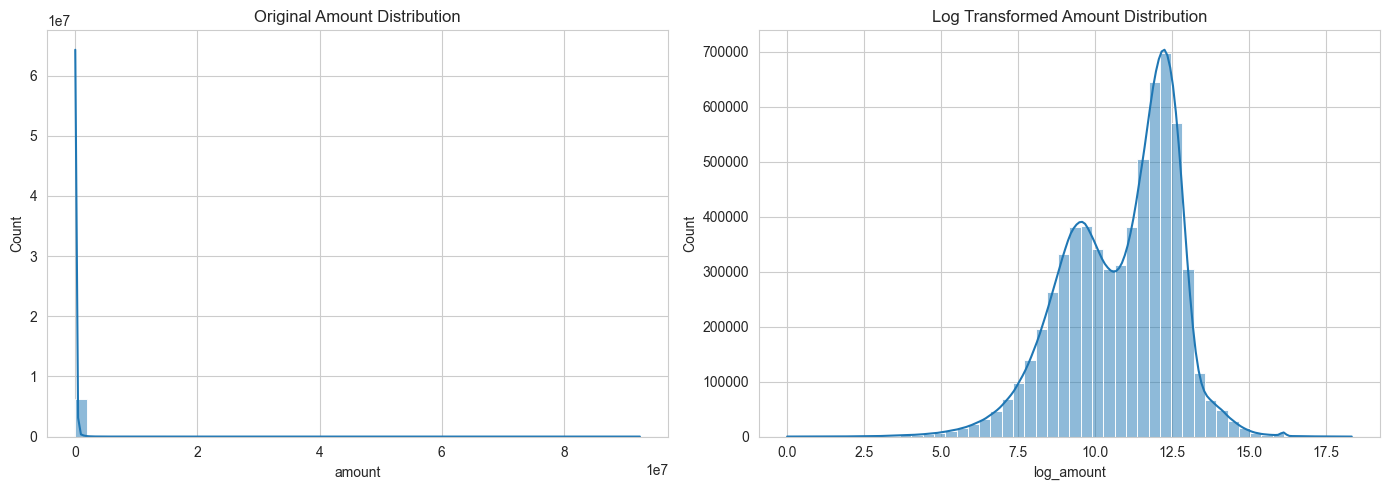

In [6]:
# Handle Skewed Amount (Log Transformation)

# Amount is highly skewed, applying log1p (log(1+x)) transformation
df["log_amount"] = np.log1p(df["amount"])

# Plot the difference
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["amount"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Original Amount Distribution")

sns.histplot(df["log_amount"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Log Transformed Amount Distribution")

plt.tight_layout()
plt.show()

In [7]:
# Checking for missing values

print("Checking for missing values:")
missing_vals = df.isnull().sum()
print(missing_vals[missing_vals > 0])
print("\nIf output is empty, it means NO missing values. Preprocessing is clean!")

Checking for missing values:
Series([], dtype: int64)

If output is empty, it means NO missing values. Preprocessing is clean!


In [9]:
# Save to the processed folder
output_path = "../transaction_data.csv"
df.to_csv(output_path, index=False)

print(f"Preprocessed data successfully saved to: {output_path}")
print("Final Shape:", df.shape)

Preprocessed data successfully saved to: ../transaction_data.csv
Final Shape: (6362620, 15)
